In [ ]:
import os
import os.path as osp
from glob import glob

import matplotlib.pyplot as plt

import sys
sys.path.append('../')
from analysis_utils import prepare_data, build_simple_target_heatmap, plot_grids
from data_utils import load_records

MAX_HEATMAP_LEGEND = 0.2
DROP_NOISE_SPANS = True

REF_ANN_PATH = os.path.realpath(
    "../color-grid-segment-annotations/data/processed_annotations/consensus_majority_clean.json"
)  # preprocessed annotations for this project
COLORGRID_ANN_PATH = os.path.realpath(
    "../color-grid-segment-annotations/data/color_grid_data.json"
)  # original annotations (formatted)
LS_DATA_PATH = os.path.realpath(
    "../color-grid-segment-annotations/data/label_studio_input/label_studio_input.json"
)  # label studio inputs

MODEL_ANNOTATION_PATH = osp.realpath('../output/generated_annotations')  # model annotations

FIG_SAVE_DIR = osp.abspath('../output/plots')
FIG_FORMAT = 'pdf'
print(f"Save plots to directory {FIG_SAVE_DIR} in format {FIG_FORMAT}")
os.makedirs(FIG_SAVE_DIR, exist_ok=True)


In [2]:
ann_df, data_df, gameids, (far_ids, split_ids, close_ids) = prepare_data(REF_ANN_PATH, COLORGRID_ANN_PATH, LS_DATA_PATH)
CONDITION_IDS = {'far': far_ids, 'split': split_ids, 'close': close_ids}

read ann data...
read source data...
add further information from label studio data...


In [ ]:
print(f'Read model annotation files from: {MODEL_ANNOTATION_PATH}')

model_file_query = osp.join(MODEL_ANNOTATION_PATH, '*.json')
MODEL_ANNOTATION_FILES = sorted([osp.abspath(p) for p in glob(model_file_query)])
print(f'Found {len(MODEL_ANNOTATION_FILES)} model annotation files:')
print(*[osp.split(f)[-1] for f in MODEL_ANNOTATION_FILES], sep='\n')

MODEL_LABELS = [os.path.splitext(os.path.basename(f))[0] for f in MODEL_ANNOTATION_FILES]

# Calculating Distributions over Target Cells

In [4]:
data = dict()

for filepath in MODEL_ANNOTATION_FILES:
    model_entry = dict()
    if "_thinking_" in filepath:
        continue  # skip files produced with thinking annotation model
    for condition in [None, "far", "split", "close"]:
        # load records for the current model and condition
        records, model_id, evaluated_system, evaluated_system_thinking, evaluated_model_label, args = load_records(
            filepath, drop_noise_spans=DROP_NOISE_SPANS, restrict_to_condition=condition, condition_ids_dict=CONDITION_IDS
        )
               
        # store evaluated model label, system and thinking flag in the model entry if not already present
        if not model_entry.get('system'):
            model_entry['system'] = osp.split(evaluated_system)[-1]
        if not model_entry.get('evaluated_model_thinking'):
            model_entry['thinking'] = evaluated_system_thinking
        
        # build heatmap counts for the current condition (or full if condition is None)
        grid_counts = build_simple_target_heatmap(records, relative=True)
        
        # store the grid counts in the model entry under the appropriate condition key
        model_entry[condition if condition else 'full'] = grid_counts
        
    
    # create a unique label for the evaluated model
    model_entry['evaluated_model_label'] = evaluated_model_label
    
    # store in data dictionary
    data[evaluated_model_label] = model_entry

  1479 rounds kept, 21 dropped (parse failure / no_reference)
  1479 rounds kept, 21 dropped (parse failure / no_reference)
restricting to condition far
  1479 rounds kept, 21 dropped (parse failure / no_reference)
restricting to condition split
  1479 rounds kept, 21 dropped (parse failure / no_reference)
restricting to condition close
  1485 rounds kept, 15 dropped (parse failure / no_reference)
  1485 rounds kept, 15 dropped (parse failure / no_reference)
restricting to condition far
  1485 rounds kept, 15 dropped (parse failure / no_reference)
restricting to condition split
  1485 rounds kept, 15 dropped (parse failure / no_reference)
restricting to condition close
  1394 rounds kept, 106 dropped (parse failure / no_reference)
  1394 rounds kept, 106 dropped (parse failure / no_reference)
restricting to condition far
  1394 rounds kept, 106 dropped (parse failure / no_reference)
restricting to condition split
  1394 rounds kept, 106 dropped (parse failure / no_reference)
restrictin

# Plot Grids

=== Qwen3.5-27B-FP8-thinking ===


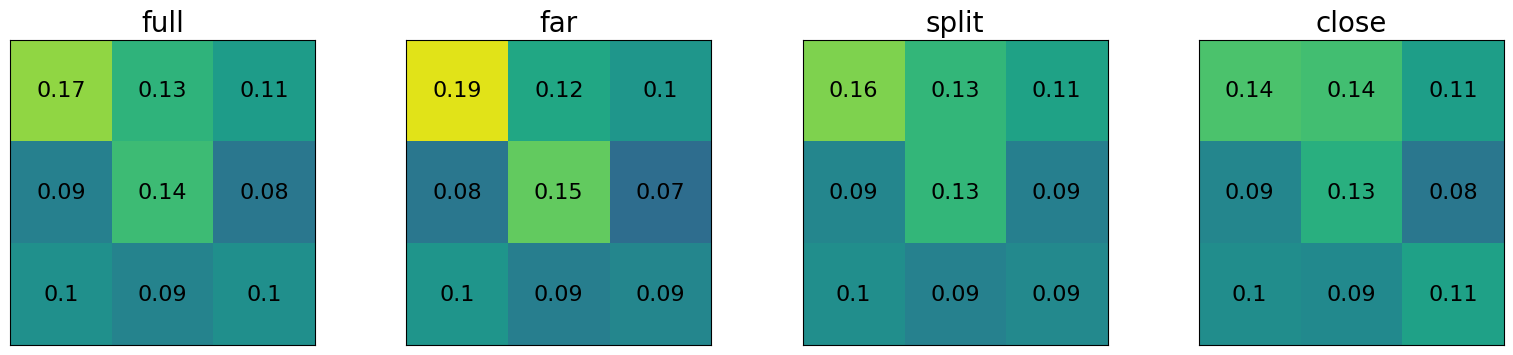

=== Qwen3.5-27B-FP8 ===


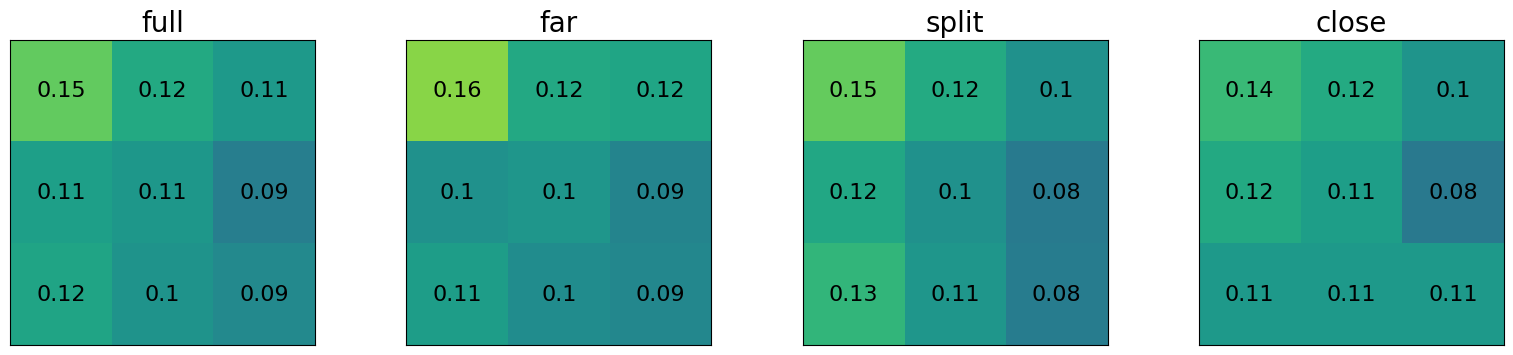

=== Qwen3.5-4B-thinking ===


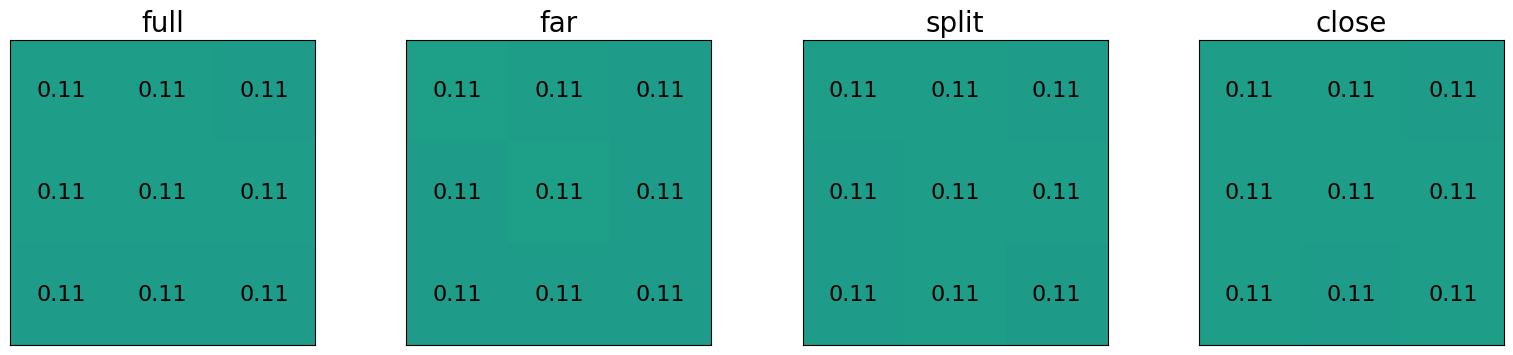

=== Qwen3.5-4B ===


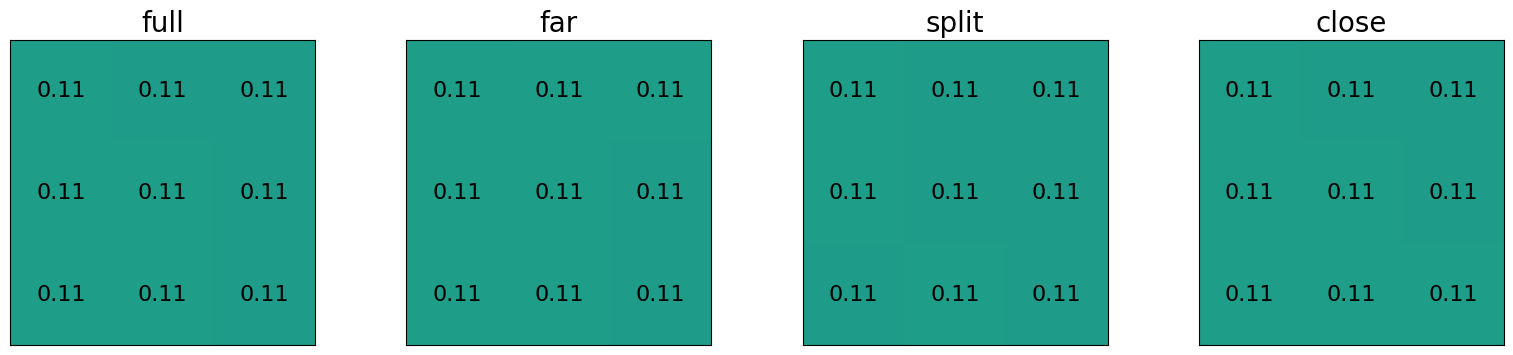

=== Qwen3.5-9B-thinking ===


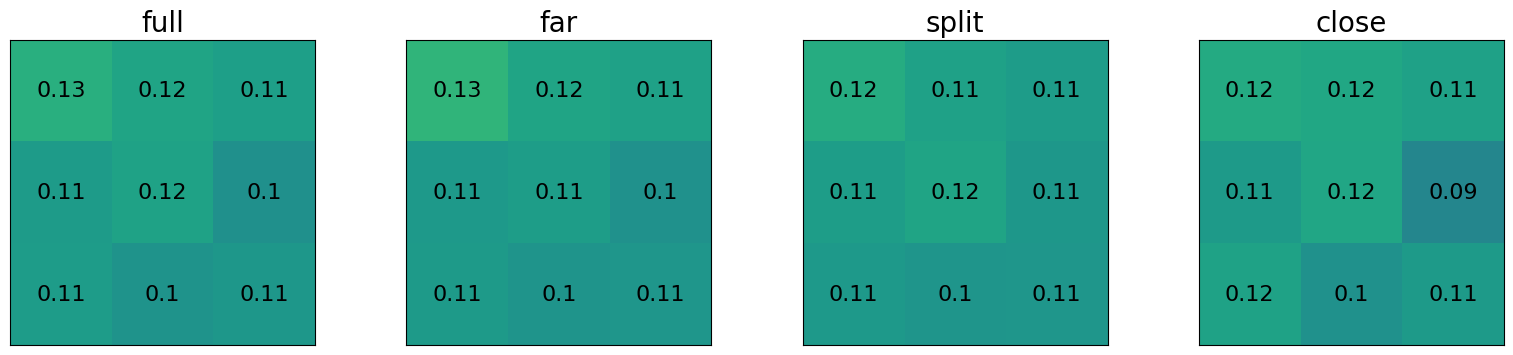

=== Qwen3.5-9B ===


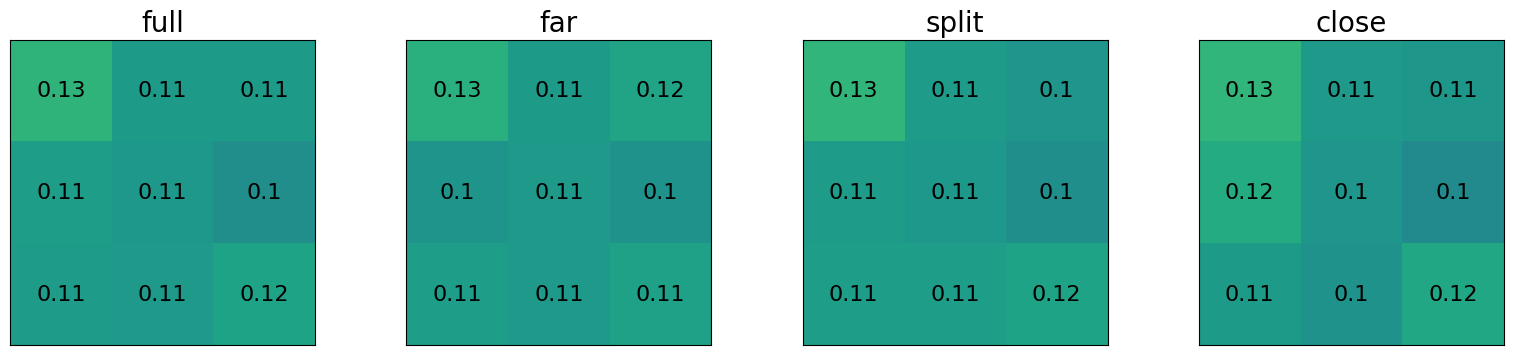

=== Qwen3.6-27B-FP8-thinking ===


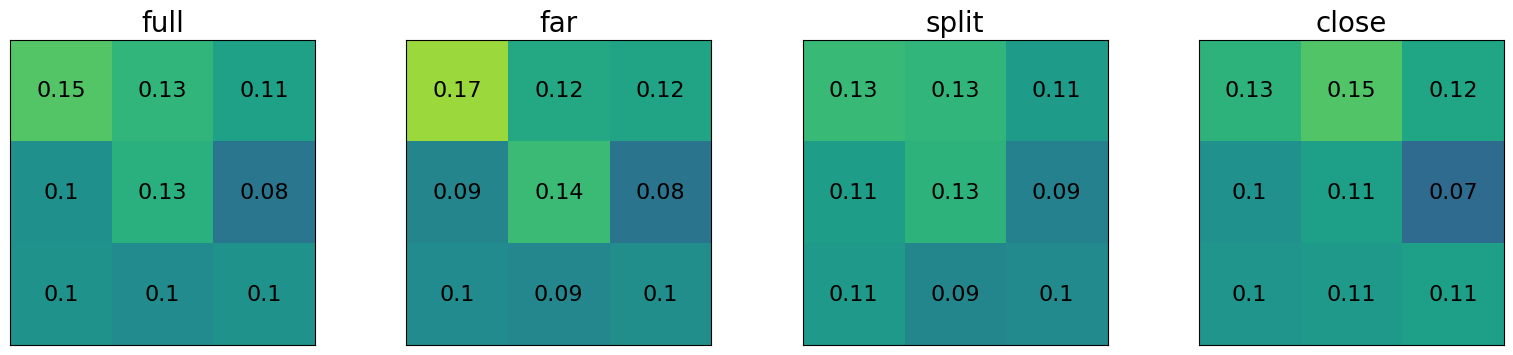

=== Qwen3.6-27B-FP8 ===


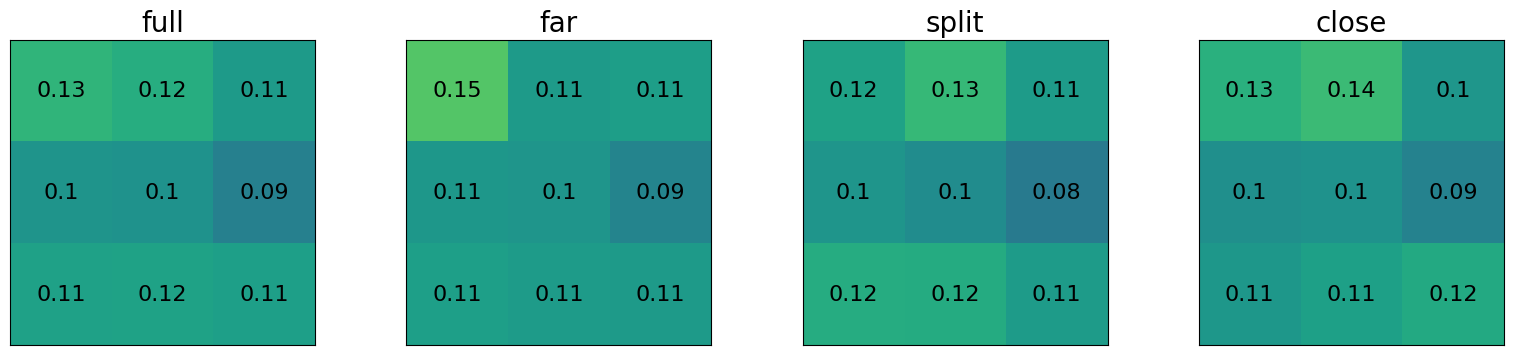

=== human ===


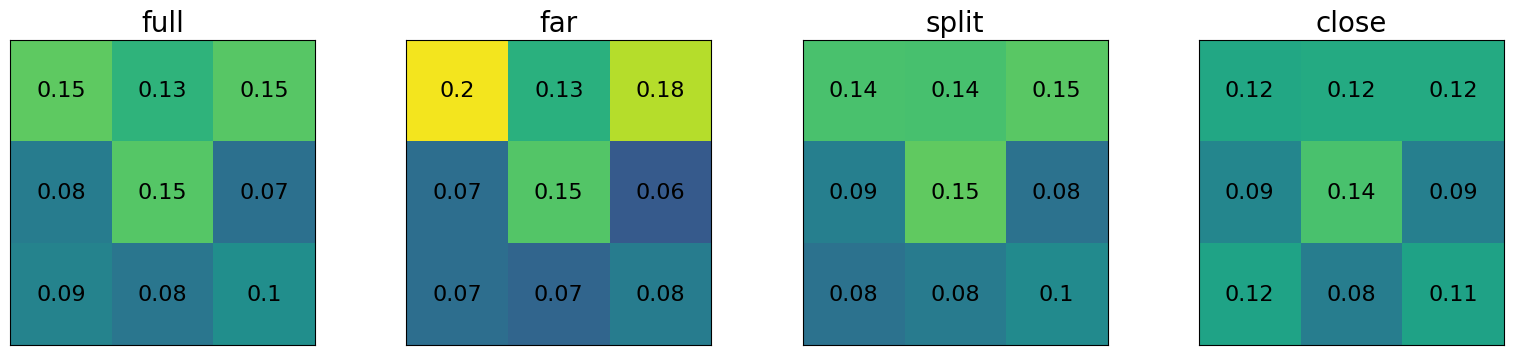

=== gemma-4-12B-it-thinking ===


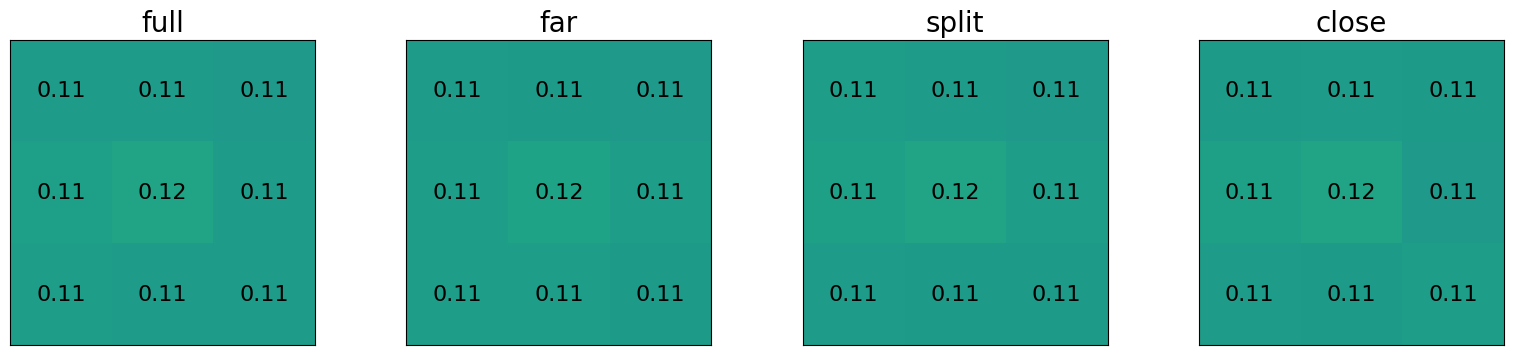

=== gemma-4-12B-it ===


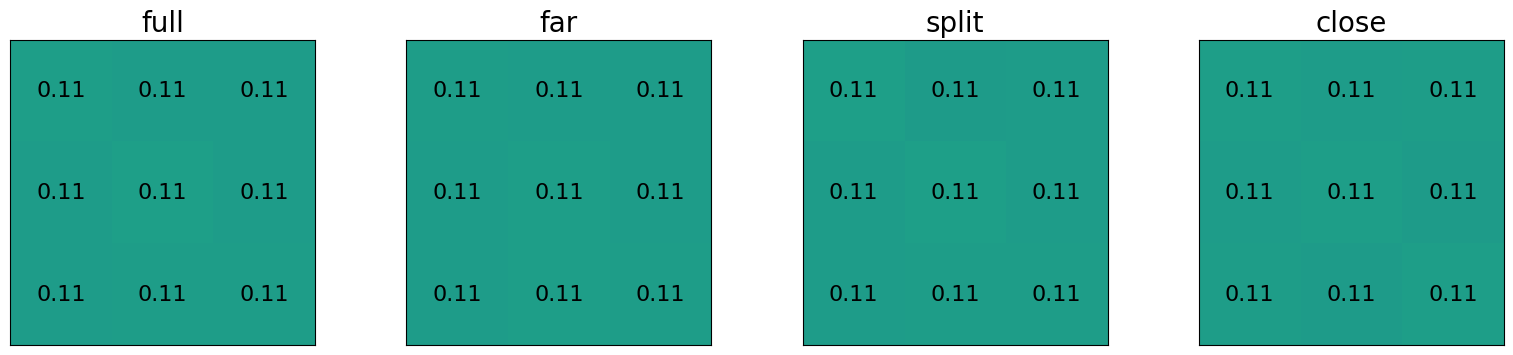

=== gemma-4-26B-A4B-it-FP8-Dynamic-thinking ===


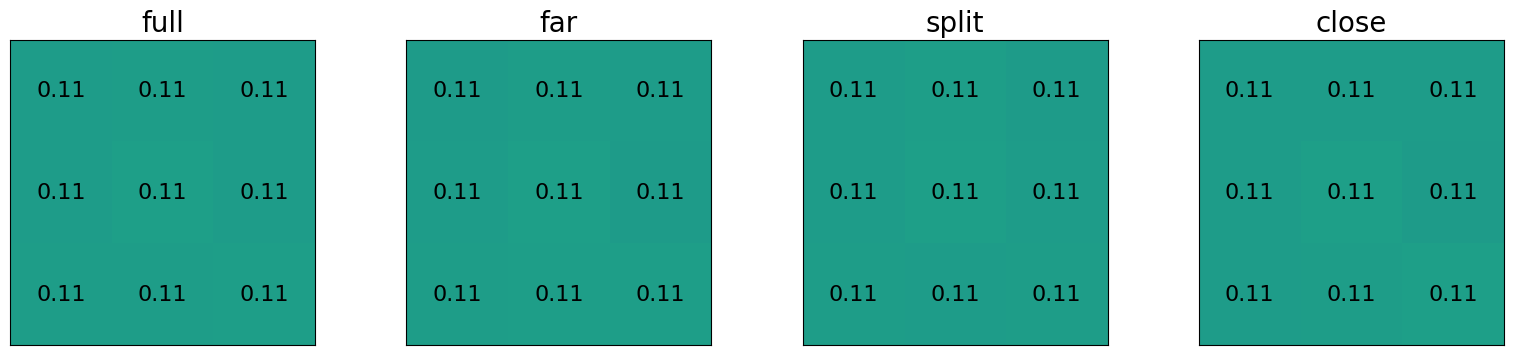

=== gemma-4-26B-A4B-it-FP8-Dynamic ===


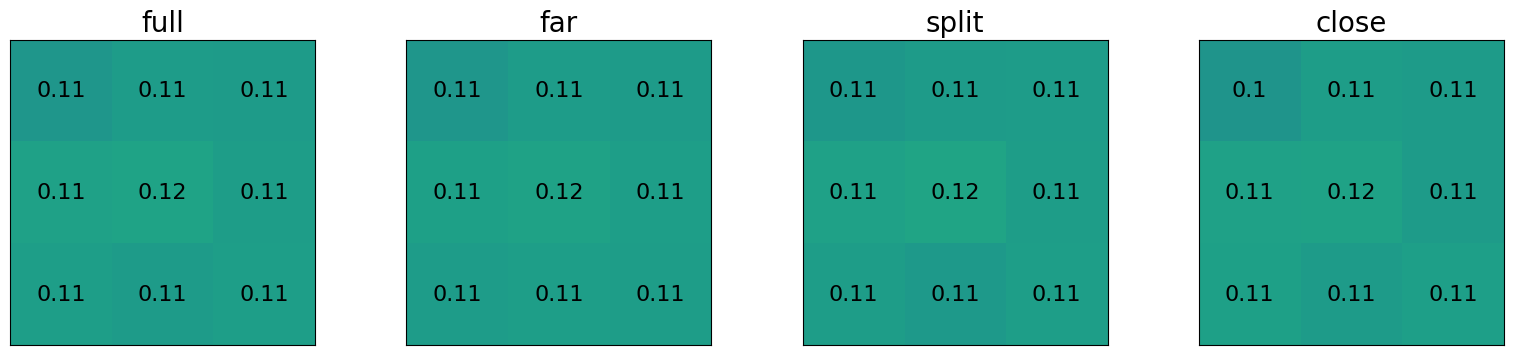

=== gemma-4-E4B-it-thinking ===


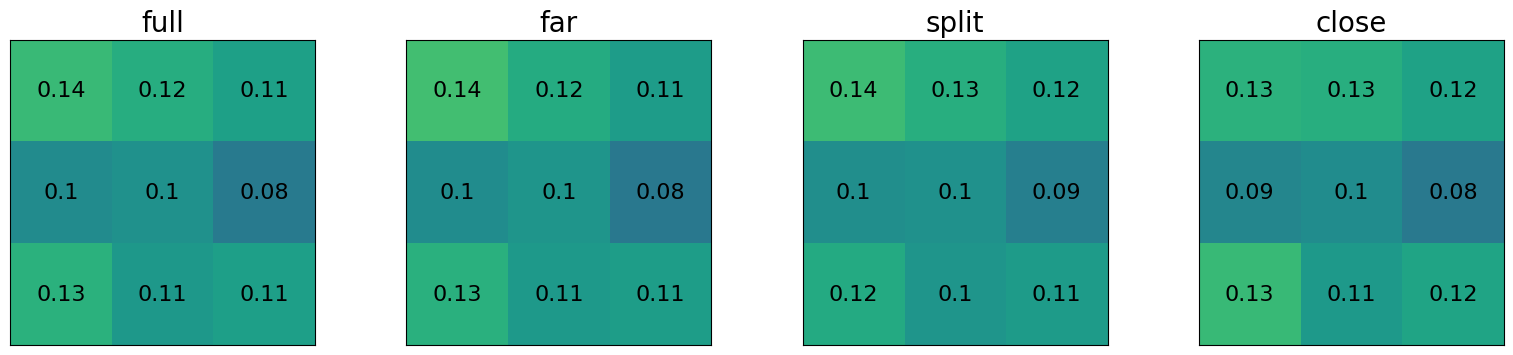

=== gemma-4-E4B-it ===


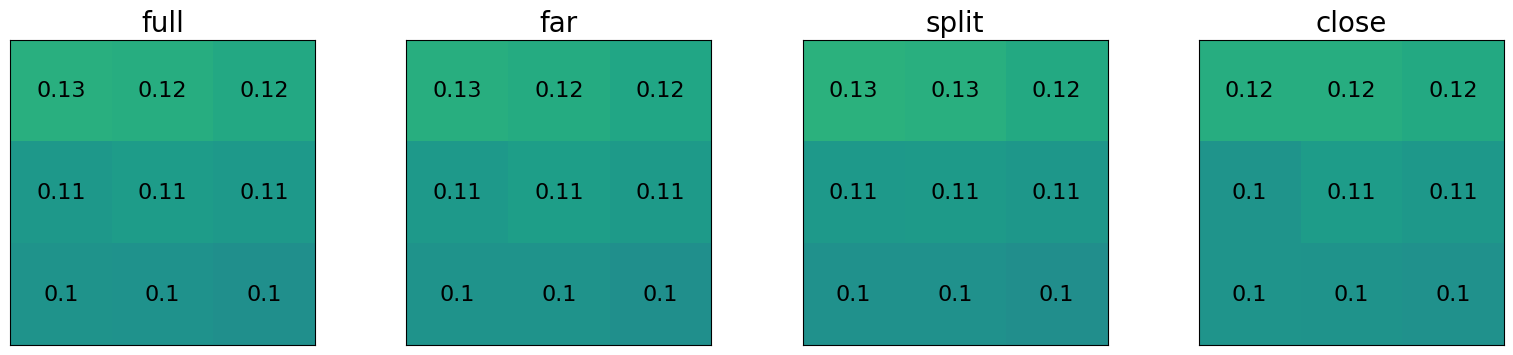

In [5]:
ADD_SUPTITLE = False
SAVE_FIGS = False

for system in data.keys():
    
    print(f"=== {system} ===")
    
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))

    # plot heatmaps for each condition as subplots
    for ax, condition in zip(axes, ["full", "far", "split", "close"]):
        grid_counts = data[system][condition]
        plot_grids(
            grid_counts,
            #title=f"{system} ({condition})",
            title=condition,
            vmax=MAX_HEATMAP_LEGEND,
            ax=ax,
            draw_colorbar=False,
            show=False
        )

    # format the figure and save
    plt.tight_layout()
    if ADD_SUPTITLE:
        plt.suptitle(system, fontsize=16, y=0.98)
    plt.subplots_adjust(top=0.8)
    if SAVE_FIGS:
        plt.savefig(osp.join(FIG_SAVE_DIR, f"{system}_heatmaps.{FIG_FORMAT}"), bbox_inches="tight")
    plt.show()